# VictoriaMetrics Anomalieerkennung mit Prophet

Dieses Notebook:
1. Liest Systemmetriken aus VictoriaMetrics
2. Transformiert die Daten in Pandas DataFrames
3. Erkennt Anomalien mit Facebook Prophet
4. Schreibt die Ergebnisse zurück nach VictoriaMetrics

In [1]:
# Abhängigkeiten prüfen und installieren
import subprocess, sys

required = {"prophet": "prophet", "requests": "requests", "pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib"}
for mod, pkg in required.items():
    try:
        __import__(mod)
    except ImportError:
        print(f"Installiere {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Alle Pakete verfügbar.")

Importing plotly failed. Interactive plots will not work.


Alle Pakete verfügbar.


In [2]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("Importe erfolgreich.")

Importe erfolgreich.


## Konfiguration

In [3]:
# VictoriaMetrics Verbindung
VM_BASE_URL = "http://ubuntu:8428"

# Metriken die abgefragt werden
METRICS = [
    'system_load5',
    'mem_used_percent',
    'rate(net_bytes_sent{interface=~"wlp1s0|eth0|wlp4s0"})',
    'rate(net_bytes_recv{interface=~"wlp1s0|eth0|wlp4s0"})',
    'rate(diskio_read_bytes{name=~"dm-1|mmcblk0"})',
    'rate(diskio_write_bytes{name=~"dm-1|mmcblk0"})',
    'netstat_tcp_established',
]

DROP_COL = ["Funktion", "its","source","alias","app"]

# Zeitraum für die historischen Daten
LOOKBACK_DAYS = 7          # Tage zurück
STEP          = "5m"       # Auflösung (z. B. 1m, 5m, 15m)

# Prophet – Konfidenzintervall für Anomalieerkennung
# Breiter (z.B. 0.99) → weniger Anomalien; schmaler (z.B. 0.90) → mehr Anomalien
INTERVAL_WIDTH = 0.995

# Präfix der zurückgeschriebenen Anomalie-Metriken
ANOMALY_PREFIX = "prophet_anomaly"

print(f"VictoriaMetrics URL : {VM_BASE_URL}")
print(f"Metriken            : {METRICS}")
print(f"Lookback            : {LOOKBACK_DAYS} Tage / Schritt: {STEP}")
print(f"Konfidenzintervall  : {INTERVAL_WIDTH*100:.0f}%")

VictoriaMetrics URL : http://ubuntu:8428
Metriken            : ['system_load5', 'mem_used_percent', 'rate(net_bytes_sent{interface=~"wlp1s0|eth0|wlp4s0"})', 'rate(net_bytes_recv{interface=~"wlp1s0|eth0|wlp4s0"})', 'rate(diskio_read_bytes{name=~"dm-1|mmcblk0"})', 'rate(diskio_write_bytes{name=~"dm-1|mmcblk0"})', 'netstat_tcp_established']
Lookback            : 7 Tage / Schritt: 5m
Konfidenzintervall  : 100%


## 1. Daten aus VictoriaMetrics laden

In [4]:
import re

def extract_metric_names(promql: str) -> list[str]:
    """
    Extrahiert alle Metrik-Namen aus einem PromQL-Ausdruck.

    Unterstützt:
    - Einfache Metriknamen:         http_requests_total
    - Mit Label-Selektoren:         http_requests_total{job="api"}
    - Funktionen:                   rate(http_requests_total[5m])
    - Regex-Selektoren:             {__name__=~"node_.*"}
    - Aggregationen:                sum by (job)(http_requests_total)
    - Verschachtelte Ausdrücke:     sum(rate(http_requests_total[5m]))
    - Binäre Operationen:           metric_a / metric_b
    """

    metric_names = set()

    # 1. Metriknamen mit optionalem Label-Selektor: metric_name{...} oder metric_name
    #    Metriknamen beginnen mit [a-zA-Z_] und enthalten [a-zA-Z0-9_:]
    pattern_named = re.compile(
        r'\b([a-zA-Z_:][a-zA-Z0-9_:]*)\s*(?:\{[^}]*\})?\s*(?:\[[\w]+\])?'
    )

    # PromQL-Keywords und Funktionen, die keine Metriknamen sind
    promql_keywords = {
        # Aggregation Operators
        'sum', 'min', 'max', 'avg', 'group', 'stddev', 'stdvar',
        'count', 'count_values', 'bottomk', 'topk', 'quantile',
        # Functions
        'rate', 'irate', 'increase', 'delta', 'idelta',
        'abs', 'absent', 'absent_over_time', 'ceil', 'floor', 'round',
        'changes', 'clamp', 'clamp_max', 'clamp_min',
        'day_of_month', 'day_of_week', 'day_of_year',
        'days_in_month', 'hour', 'minute', 'month', 'year',
        'exp', 'ln', 'log2', 'log10', 'sqrt',
        'histogram_quantile', 'histogram_count', 'histogram_sum',
        'holt_winters', 'label_join', 'label_replace',
        'predict_linear', 'resets', 'sort', 'sort_desc',
        'timestamp', 'vector', 'scalar',
        'deriv', 'last_over_time', 'max_over_time', 'min_over_time',
        'avg_over_time', 'sum_over_time', 'count_over_time',
        'quantile_over_time', 'stddev_over_time', 'stdvar_over_time',
        'mad_over_time', 'present_over_time',
        # Modifiers
        'by', 'without', 'on', 'ignoring', 'group_left', 'group_right',
        'offset', 'bool', 'and', 'or', 'unless',
        # Literals die als Identifier aussehen könnten
        'inf', 'nan', 'true', 'false',
    }

    for match in pattern_named.finditer(promql):
        name = match.group(1)
        if name not in promql_keywords:
            metric_names.add(name)

    # 2. Regex-basierte Metriknamen aus __name__=~"..." extrahieren
    pattern_name_regex = re.compile(
        r'__name__\s*=~?\s*["\']([^"\']+)["\']'
    )
    for match in pattern_name_regex.finditer(promql):
        metric_names.add(match.group(1))  # Regex-Pattern als Hinweis behalten

    return sorted(metric_names)


In [5]:
def query_range(metric: str, start: datetime, end: datetime, step: str = "5m") -> pd.DataFrame:
    """Abfrage einer Metrik aus VictoriaMetrics, Rückgabe als DataFrame."""
    url = f"{VM_BASE_URL}/api/v1/query_range"
    params = {
        "query": metric,
        "start": int(start.timestamp()),
        "end":   int(end.timestamp()),
        "step":  step,
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    if data["status"] != "success":
        raise RuntimeError(f"Query fehlgeschlagen: {data.get('error', 'unbekannt')}")

    rows = []
    metric=extract_metric_names(metric)[0]
    for series in data["data"]["result"]:
        labels = series["metric"]
        for ts, val in series["values"]:
            row = {
                "ds":       pd.Timestamp(ts, unit="s", tz="UTC"),
                "y":        float(val),
                "__name__": labels.get("__name__", metric),
            }
            row.update({k: v for k, v in labels.items() if k != "__name__"})
            rows.append(row)

    if not rows:
        return pd.DataFrame(columns=["ds", "y", "__name__"])

    df = pd.DataFrame(rows)
    df = df.drop(columns=DROP_COL)
    # Prophet braucht zeitzonennaive Timestamps
    df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None) #(None)
    return df


end_ts   = datetime.utcnow()
start_ts = end_ts - timedelta(days=LOOKBACK_DAYS)

print(f"Zeitraum: {start_ts:%Y-%m-%d %H:%M} – {end_ts:%Y-%m-%d %H:%M} UTC\n")

raw_data: dict[str, pd.DataFrame] = {}

for metric in METRICS:
    # metric=extract_metric_names(metric)[0]
    try:
        df = query_range(metric, start_ts, end_ts, STEP)
        metric=extract_metric_names(metric)[0]
        raw_data[metric] = df
        label_cols = [c for c in df.columns if c not in ("ds", "y", "__name__")]
        n_series = df[label_cols].drop_duplicates().shape[0] if label_cols and not df.empty else 1
        status = f"{len(df):6d} Punkte, {n_series} Serie(n)" if not df.empty else "KEINE DATEN"
        print(f"  {metric:35s} → {status}")
    except Exception as e:
        print(f"  {metric:35s} → FEHLER: {e}")
        raw_data[metric] = pd.DataFrame(columns=["ds", "y", "__name__"])
df.info()


Zeitraum: 2026-05-28 09:01 – 2026-06-04 09:01 UTC

  system_load5                        →   3551 Punkte, 3 Serie(n)
  mem_used_percent                    →   3551 Punkte, 3 Serie(n)
  net_bytes_sent                      →   3560 Punkte, 3 Serie(n)
  net_bytes_recv                      →   3560 Punkte, 3 Serie(n)
  diskio_read_bytes                   →   3560 Punkte, 3 Serie(n)
  diskio_write_bytes                  →   3560 Punkte, 3 Serie(n)
  netstat_tcp_established             →   3551 Punkte, 3 Serie(n)
<class 'pandas.DataFrame'>
RangeIndex: 3551 entries, 0 to 3550
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   ds        3551 non-null   datetime64[s]
 1   y         3551 non-null   float64      
 2   __name__  3551 non-null   str          
 3   host      3551 non-null   str          
 4   instance  3551 non-null   str          
dtypes: datetime64[s](1), float64(1), str(3)
memory usage: 138.8 KB


## 2. Pandas DataFrames – Übersicht

In [6]:
for metric, df in raw_data.items():
    if df.empty:
        print(f"{metric}: keine Daten\n")
        continue
    label_cols = [c for c in df.columns if c not in ("ds", "y", "__name__")]
    print(f"{'='*60}")
    print(f"Metrik  : {metric}")
    print(f"Zeilen  : {len(df):,}")
    print(f"Zeitraum: {df['ds'].min()} → {df['ds'].max()}")
    print(f"Werte   : min={df['y'].min():.4g}  max={df['y'].max():.4g}  mean={df['y'].mean():.4g}")
    if label_cols:
        uniq = df[label_cols].drop_duplicates()
        print(f"Serien ({len(uniq)}):")
        for _, row in uniq.iterrows():
            print(f"  {dict(row)}")
    print()

Metrik  : system_load5
Zeilen  : 3,551
Zeitraum: 2026-05-28 07:00:00 → 2026-06-04 07:00:00
Werte   : min=0  max=3.76  mean=0.431
Serien (3):
  {'host': 'nbx1', 'instance': 'nbx1.home.de'}
  {'host': 'x13', 'instance': 'x13.home.de'}
  {'host': 'ubuntu', 'instance': 'ubuntu.home.de'}

Metrik  : mem_used_percent
Zeilen  : 3,551
Zeitraum: 2026-05-28 07:00:00 → 2026-06-04 07:00:00
Werte   : min=10.17  max=93.04  mean=27.12
Serien (3):
  {'host': 'nbx1', 'instance': 'nbx1.home.de'}
  {'host': 'x13', 'instance': 'x13.home.de'}
  {'host': 'ubuntu', 'instance': 'ubuntu.home.de'}

Metrik  : net_bytes_sent
Zeilen  : 3,560
Zeitraum: 2026-05-28 07:00:00 → 2026-06-04 07:00:00
Werte   : min=0  max=4.049e+06  mean=2.238e+04
Serien (3):
  {'host': 'nbx1', 'instance': 'nbx1.home.de', 'interface': 'wlp4s0'}
  {'host': 'x13', 'instance': 'x13.home.de', 'interface': 'wlp1s0'}
  {'host': 'ubuntu', 'instance': 'ubuntu.home.de', 'interface': 'eth0'}

Metrik  : net_bytes_recv
Zeilen  : 3,560
Zeitraum: 2026-05

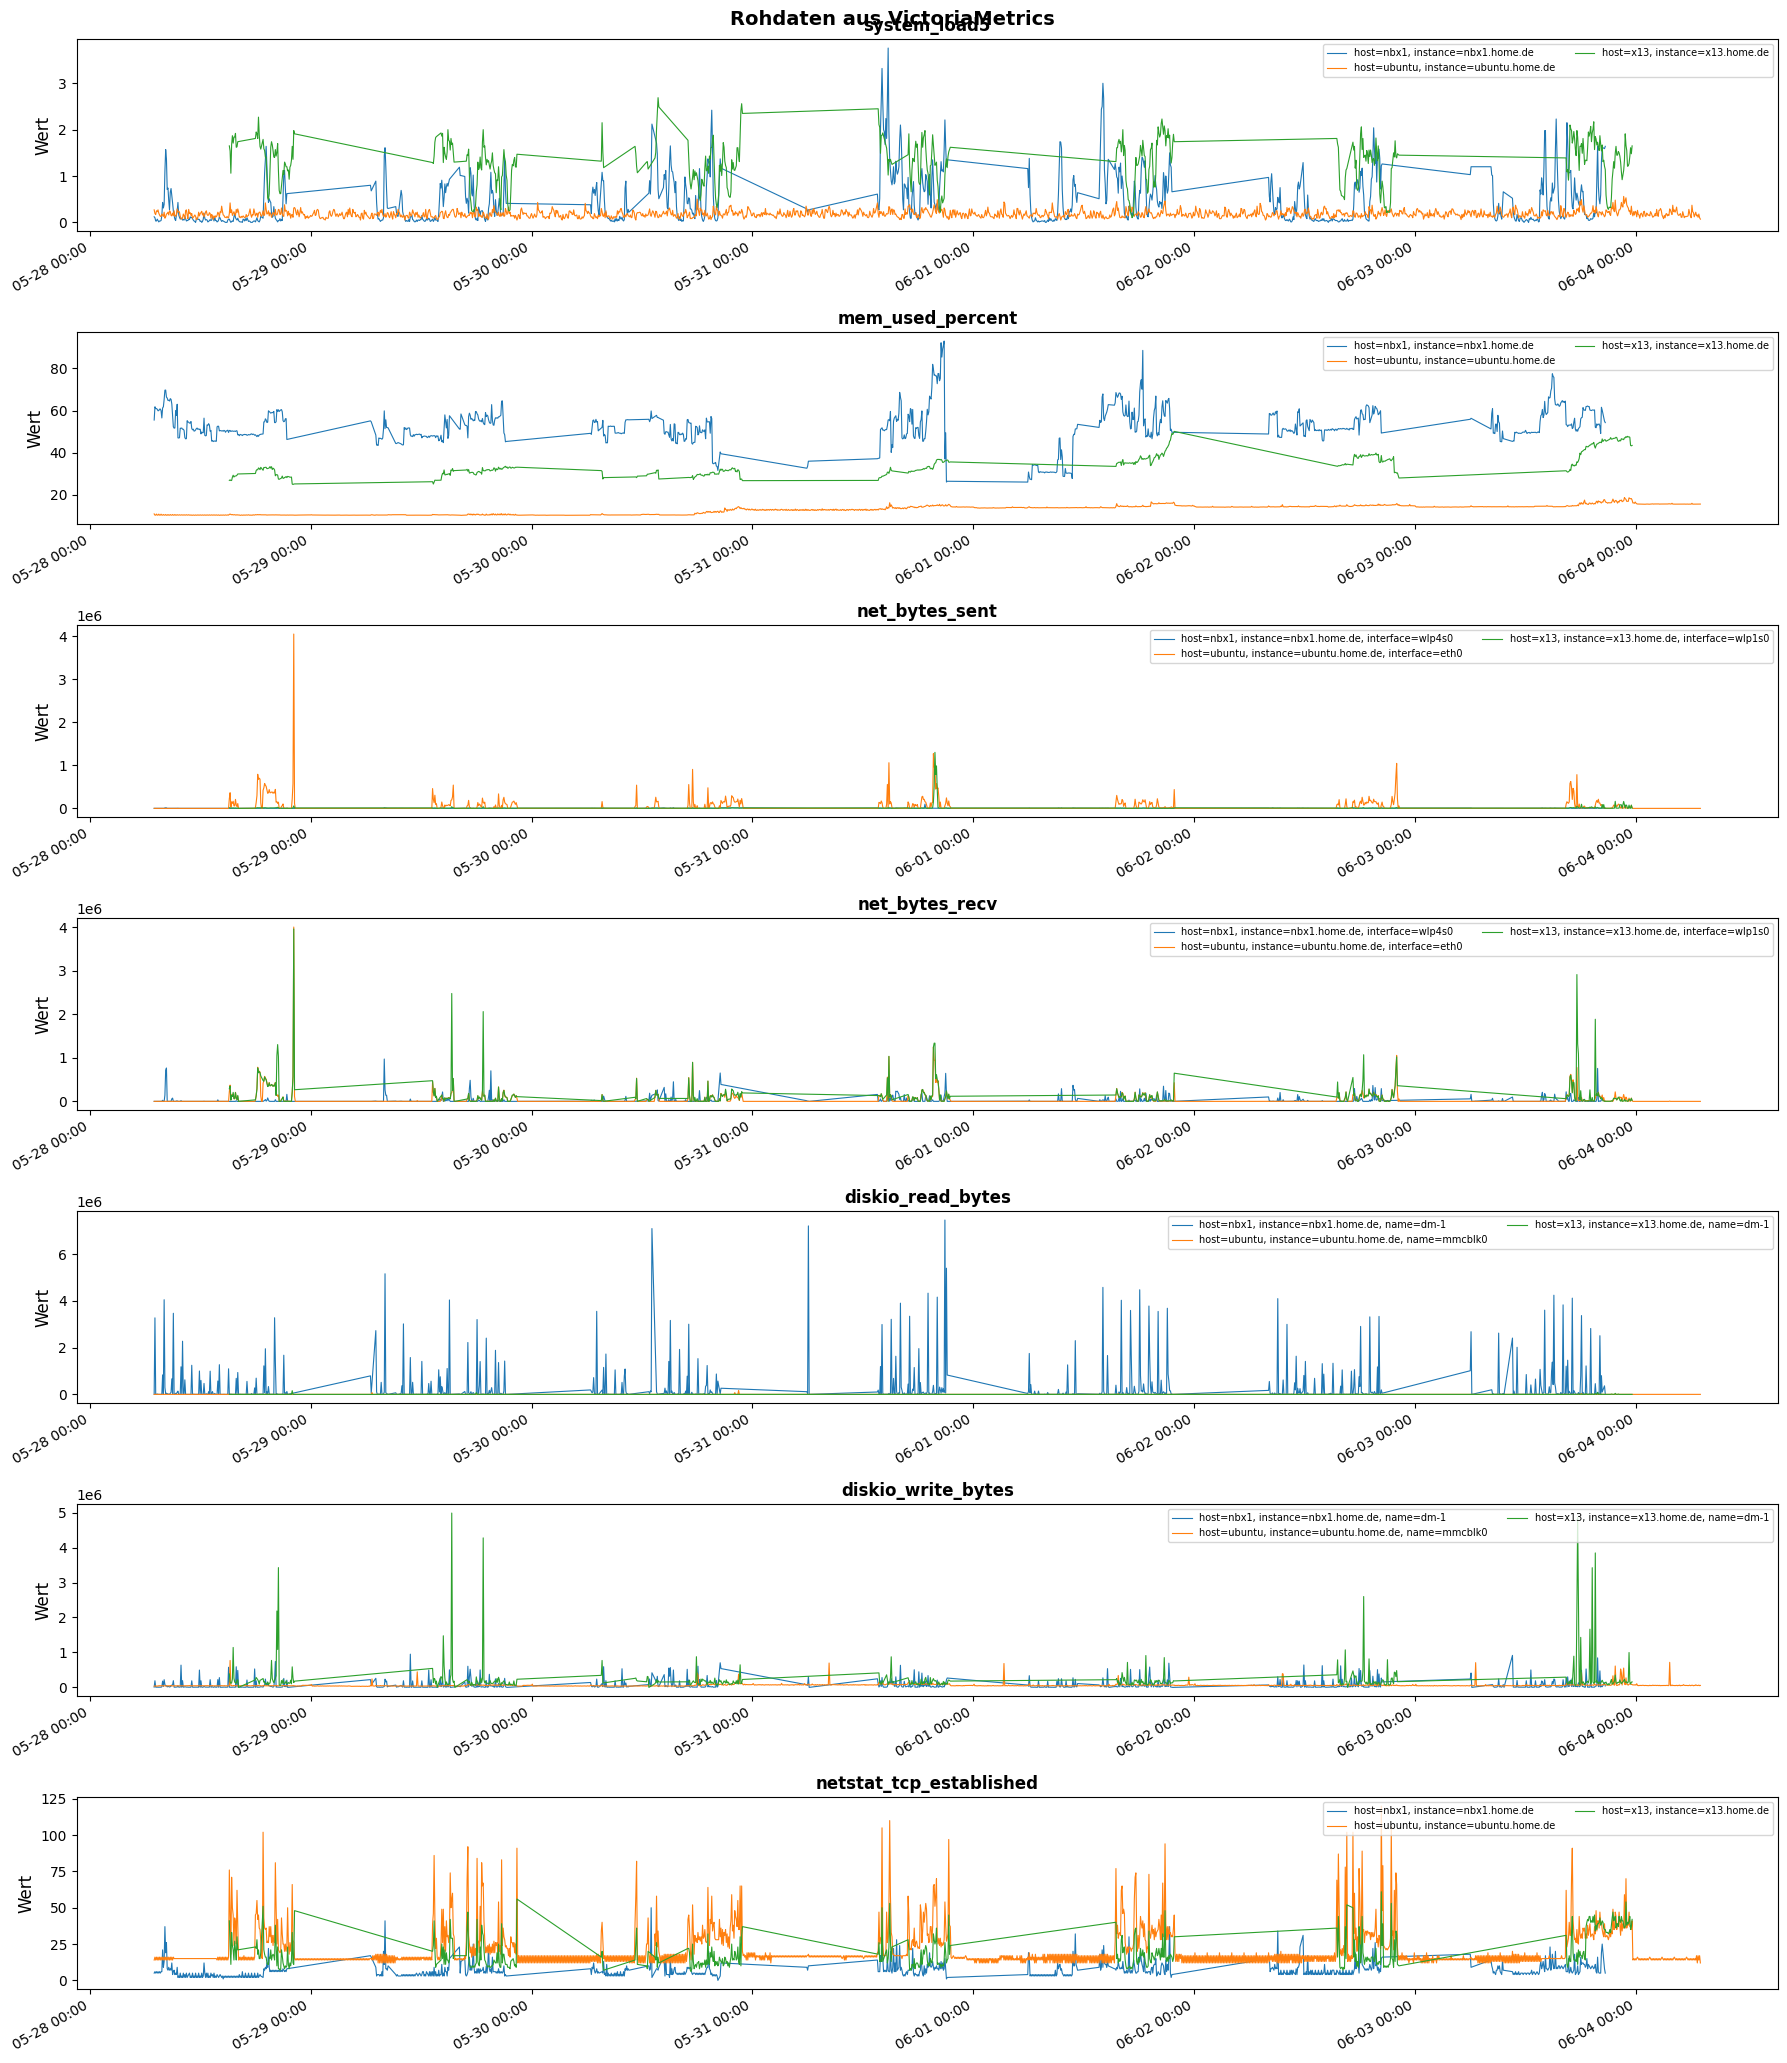

In [7]:
# Rohdaten visualisieren
fig, axes = plt.subplots(len(METRICS), 1, figsize=(18, 3 * len(METRICS)), sharex=False)
if len(METRICS) == 1:
    axes = [axes]
fig.suptitle("Rohdaten aus VictoriaMetrics", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, METRICS):
    metric=extract_metric_names(metric)[0]
    df = raw_data[metric]
    if df.empty:
        ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_title(metric)
        continue

    label_cols = [c for c in df.columns if c not in ("ds", "y", "__name__")]
    if label_cols:
        for key, grp in df.groupby(label_cols):
            lbl = key if isinstance(key, str) else ", ".join(f"{k}={v}" for k, v in zip(label_cols, key))
            ax.plot(grp["ds"], grp["y"], linewidth=0.8, label=str(lbl))
        if df[label_cols].drop_duplicates().shape[0] > 1:
            ax.legend(fontsize=7, loc="upper right", ncol=2)
    else:
        ax.plot(df["ds"], df["y"], linewidth=0.8, color="steelblue")

    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel("Wert", fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Anomalieerkennung mit Prophet

Prophet erstellt ein Vorhersagemodell mit Trend + Saisonalität.
Datenpunkte außerhalb des Konfidenzintervalls `[yhat_lower, yhat_upper]` werden als **Anomalien** markiert.

In [8]:
def detect_anomalies_prophet(
    df: pd.DataFrame,
    interval_width: float = 0.99,
) -> pd.DataFrame:
    """
    Führt Prophet-Anomalieerkennung auf dem DataFrame durch.
    Erwartet Spalten: ds, y  (+ optionale Label-Spalten für mehrere Serien).
    Gibt df mit zusätzlichen Spalten yhat, yhat_lower, yhat_upper, anomaly zurück.
    """
    if df.empty:
        return df.assign(yhat=np.nan, yhat_lower=np.nan, yhat_upper=np.nan, anomaly=0)

    label_cols = [c for c in df.columns if c not in ("ds", "y", "__name__")]
    groups     = df.groupby(label_cols) if label_cols else [(None, df)]

    parts = []
    for key, grp in groups:
        grp   = grp.sort_values("ds").copy()
        train = grp[["ds", "y"]].dropna()

        if len(train) < 10:
            grp = grp.assign(yhat=np.nan, yhat_lower=np.nan, yhat_upper=np.nan, anomaly=0)
            parts.append(grp)
            continue

        # Dauer des Datensatzes entscheidet über Saisonalitäten
        duration_h = (train["ds"].max() - train["ds"].min()).total_seconds() / 3600
        weekly     = duration_h >= 48

        model = Prophet(
            interval_width        = interval_width,
            daily_seasonality     = True,
            weekly_seasonality    = weekly,
            yearly_seasonality    = False,
            changepoint_prior_scale = 0.05,
        )
        model.fit(train)

        forecast = model.predict(train[["ds"]])
        grp = grp.merge(
            forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
            on="ds", how="left"
        )
        grp["anomaly"] = (
            (grp["y"] < grp["yhat_lower"]) | (grp["y"] > grp["yhat_upper"])
        ).astype(int)
        parts.append(grp)

    return pd.concat(parts, ignore_index=True) if parts else df


print("Starte Anomalieerkennung...\n")
anomaly_data: dict[str, pd.DataFrame] = {}

for metric in METRICS:
    metric=extract_metric_names(metric)[0]
    df = raw_data[metric]
    if df.empty:
        print(f"  {metric:35s} → übersprungen (keine Daten)")
        anomaly_data[metric] = df
        continue

    print(f"  {metric:35s} → ", end="", flush=True)
    try:
        result = detect_anomalies_prophet(df, interval_width=INTERVAL_WIDTH)
        n_anom = int(result["anomaly"].sum())
        n_tot  = len(result)
        print(f"{n_anom:4d} / {n_tot:5d} Anomalien ({n_anom/n_tot*100:.1f}%)")
        anomaly_data[metric] = result
    except Exception as e:
        print(f"FEHLER: {e}")
        anomaly_data[metric] = df

print("\nFertig.")

Starte Anomalieerkennung...

  system_load5                        → 

11:01:20 - cmdstanpy - INFO - Chain [1] start processing
11:01:20 - cmdstanpy - INFO - Chain [1] done processing
11:01:20 - cmdstanpy - INFO - Chain [1] start processing
11:01:20 - cmdstanpy - INFO - Chain [1] done processing
11:01:20 - cmdstanpy - INFO - Chain [1] start processing
11:01:20 - cmdstanpy - INFO - Chain [1] done processing


  47 /  3551 Anomalien (1.3%)
  mem_used_percent                    → 

11:01:20 - cmdstanpy - INFO - Chain [1] start processing
11:01:20 - cmdstanpy - INFO - Chain [1] done processing
11:01:21 - cmdstanpy - INFO - Chain [1] start processing
11:01:21 - cmdstanpy - INFO - Chain [1] done processing
11:01:21 - cmdstanpy - INFO - Chain [1] start processing
11:01:21 - cmdstanpy - INFO - Chain [1] done processing


  66 /  3551 Anomalien (1.9%)
  net_bytes_sent                      → 

...

  51 /  3560 Anomalien (1.4%)
  diskio_write_bytes                  → 

11:01:23 - cmdstanpy - INFO - Chain [1] start processing
11:01:23 - cmdstanpy - INFO - Chain [1] done processing
11:01:23 - cmdstanpy - INFO - Chain [1] start processing
11:01:23 - cmdstanpy - INFO - Chain [1] done processing
11:01:23 - cmdstanpy - INFO - Chain [1] start processing
11:01:23 - cmdstanpy - INFO - Chain [1] done processing


  74 /  3560 Anomalien (2.1%)
  netstat_tcp_established             → 

11:01:23 - cmdstanpy - INFO - Chain [1] start processing
11:01:23 - cmdstanpy - INFO - Chain [1] done processing
11:01:23 - cmdstanpy - INFO - Chain [1] start processing
11:01:23 - cmdstanpy - INFO - Chain [1] done processing
11:01:24 - cmdstanpy - INFO - Chain [1] start processing
11:01:24 - cmdstanpy - INFO - Chain [1] done processing


 104 /  3551 Anomalien (2.9%)

Fertig.


## 4. Anomalieergebnisse visualisieren

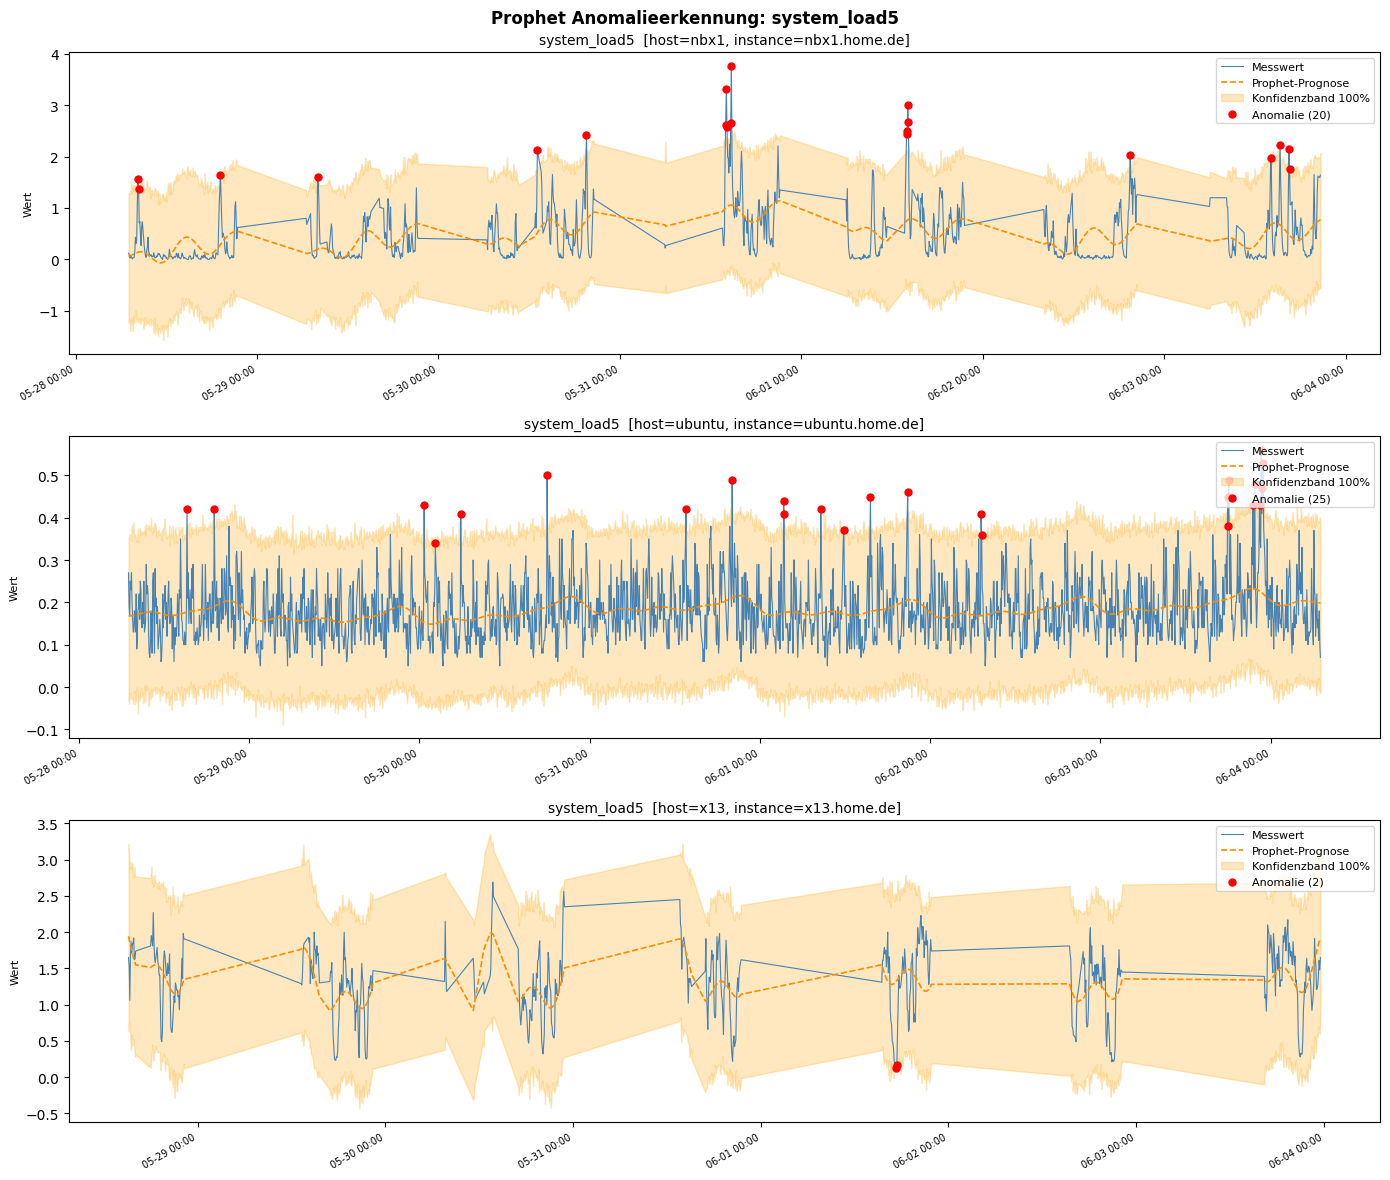

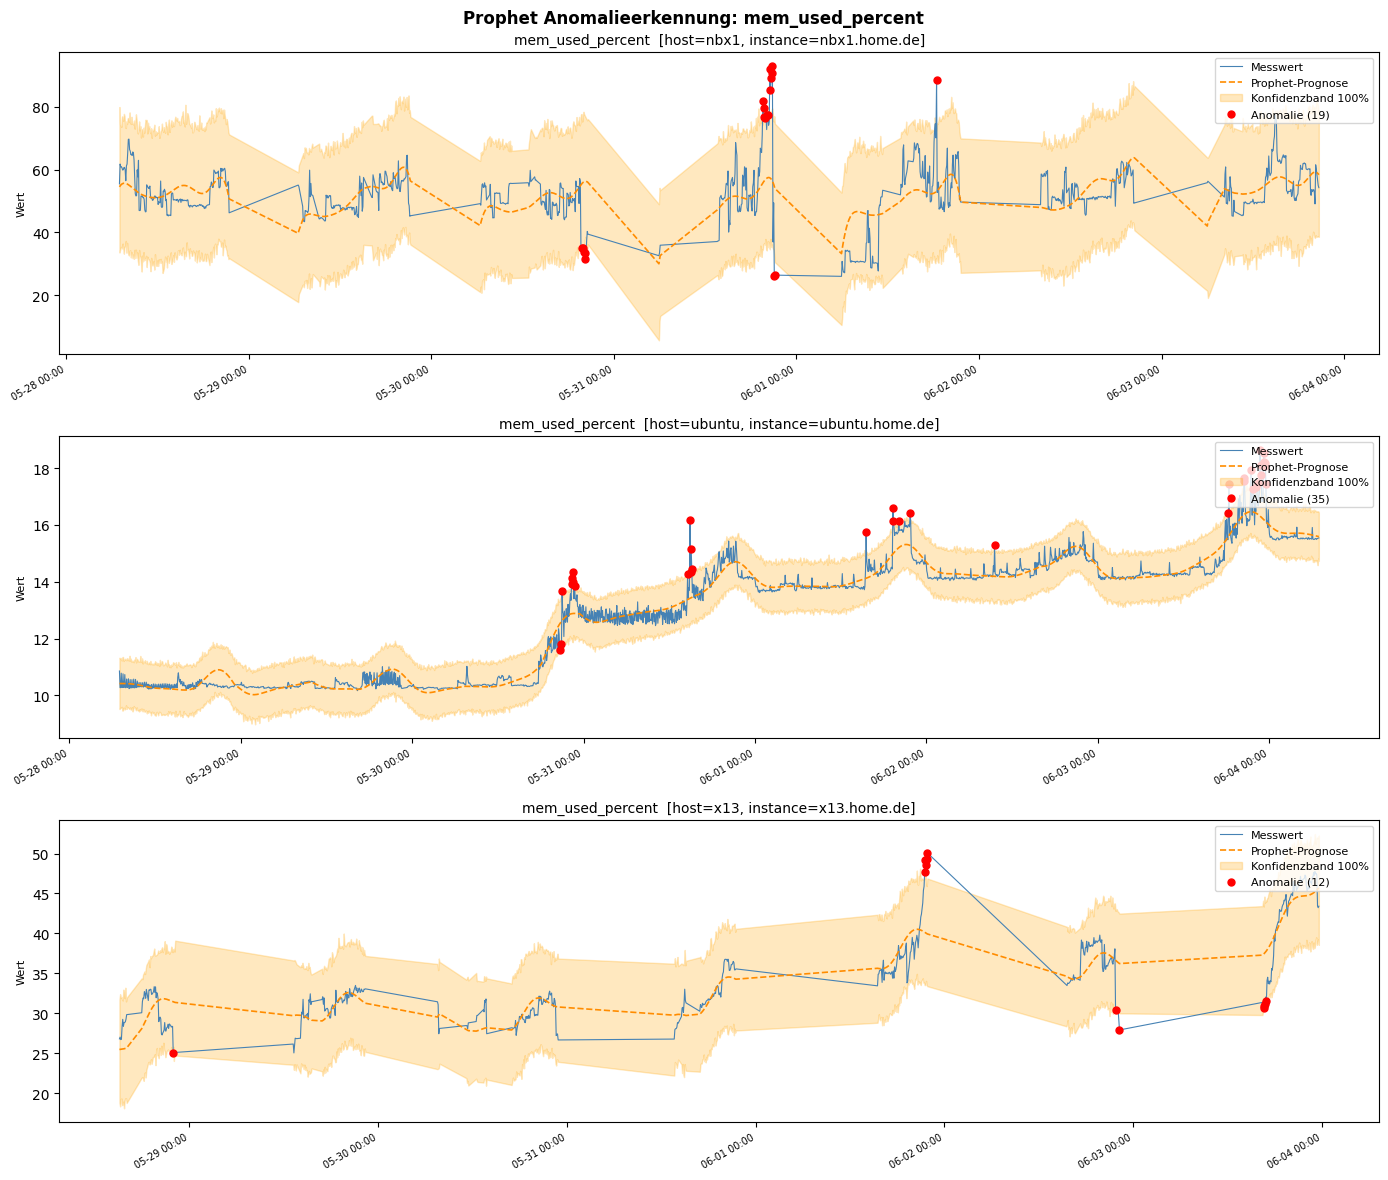

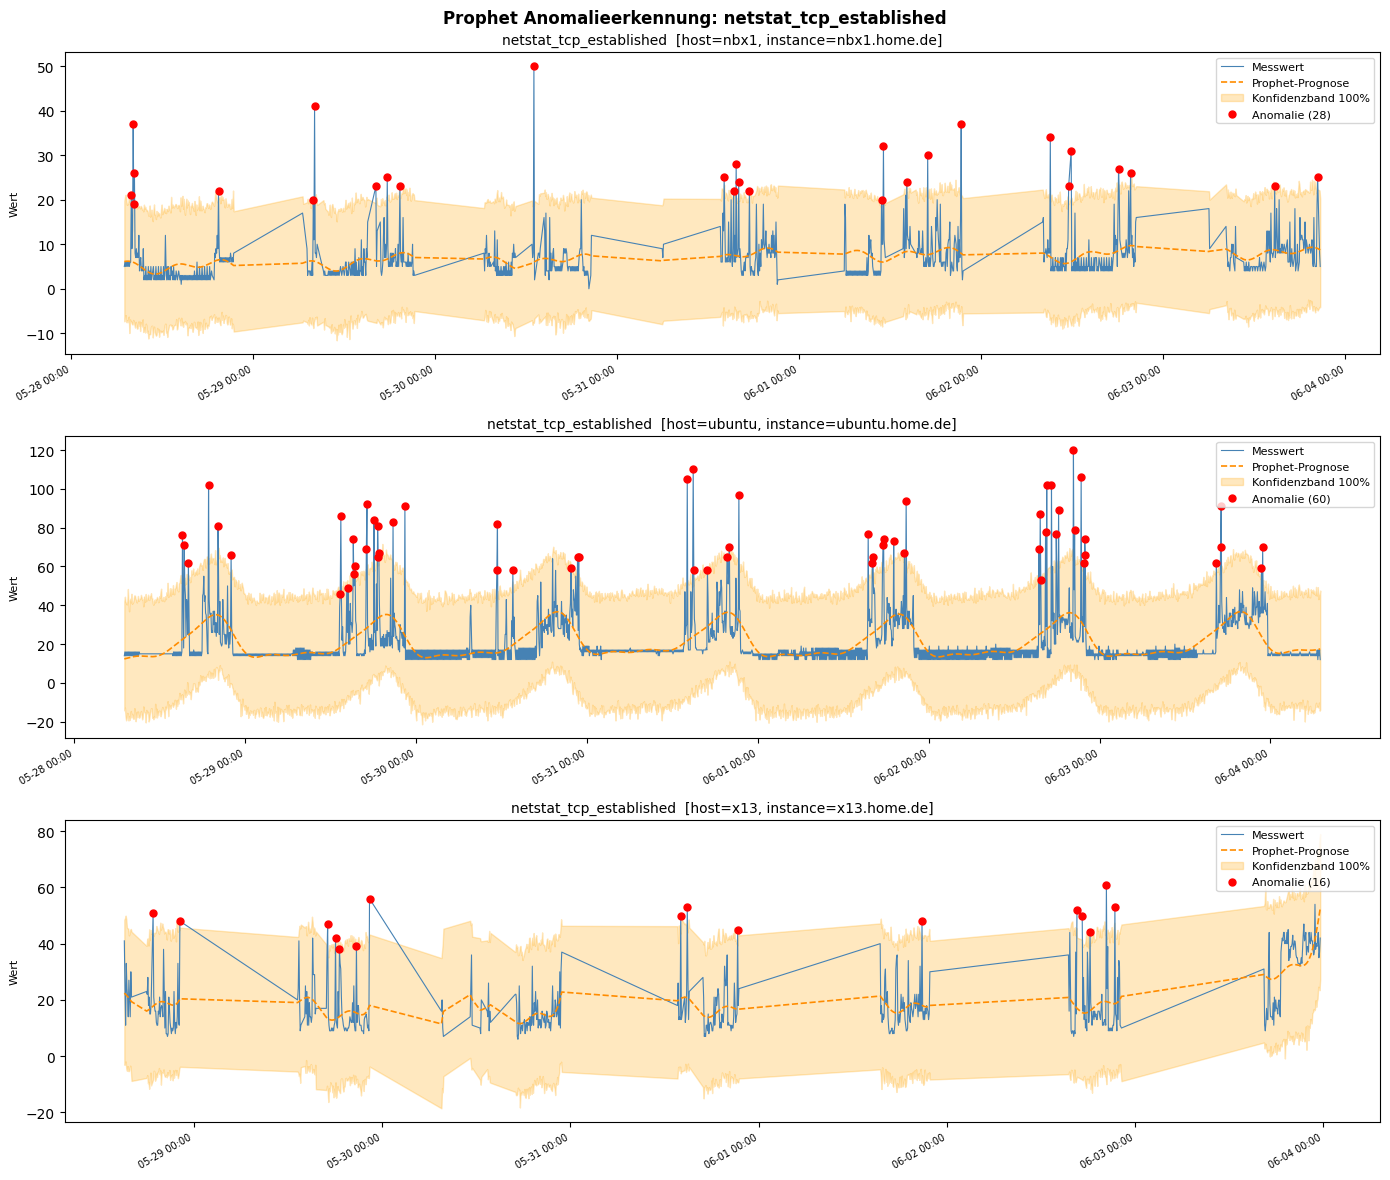

In [10]:
for metric in METRICS:
    df = anomaly_data.get(metric, pd.DataFrame())
    if df.empty or "anomaly" not in df.columns:
        continue

    label_cols = [c for c in df.columns if c not in ("ds", "y", "__name__", "yhat", "yhat_lower", "yhat_upper", "anomaly")]
    groups     = list(df.groupby(label_cols) if label_cols else [(None, df)])
    n_groups   = len(groups)

    fig, axes = plt.subplots(n_groups, 1, figsize=(14, 4 * n_groups), squeeze=False)
    fig.suptitle(f"Prophet Anomalieerkennung: {metric}", fontsize=12, fontweight="bold")

    for ax, (key, grp) in zip(axes.flatten(), groups):
        grp = grp.sort_values("ds")

        if key is not None:
            lbl = key if isinstance(key, str) else ", ".join(f"{k}={v}" for k, v in zip(label_cols, key))
            subtitle = f"  [{lbl}]"
        else:
            subtitle = ""

        # Messwert
        ax.plot(grp["ds"], grp["y"], color="steelblue", linewidth=0.8, label="Messwert")

        # Prognose + Konfidenzband
        if "yhat" in grp.columns and grp["yhat"].notna().any():
            ax.plot(grp["ds"], grp["yhat"], color="darkorange", linewidth=1.2,
                    linestyle="--", label="Prophet-Prognose")
            ax.fill_between(
                grp["ds"], grp["yhat_lower"], grp["yhat_upper"],
                alpha=0.25, color="orange",
                label=f"Konfidenzband {INTERVAL_WIDTH*100:.0f}%"
            )

        # Anomalien
        anom = grp[grp["anomaly"] == 1]
        if not anom.empty:
            ax.scatter(anom["ds"], anom["y"], color="red", s=25, zorder=5,
                       label=f"Anomalie ({len(anom)})")

        ax.set_title(f"{metric}{subtitle}", fontsize=10)
        ax.set_ylabel("Wert", fontsize=8)
        ax.legend(fontsize=8, loc="upper right")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

    plt.tight_layout()
    plt.show()

## 5. Ergebnisse nach VictoriaMetrics schreiben

Folgende Metriken werden in VictoriaMetrics importiert:

| Metrik | Beschreibung |
|---|---|
| `prophet_anomaly_flag` | 1 = Anomalie, 0 = normal |
| `prophet_anomaly_predicted` | Vorhergesagter Wert (yhat) |
| `prophet_anomaly_predicted_lower` | Untere Konfidenzgrenze |
| `prophet_anomaly_predicted_upper` | Obere Konfidenzgrenze |

Alle Metriken tragen das Label `source_metric` mit dem originalen Metriknamen.

In [11]:
def build_prometheus_lines(metric: str, df: pd.DataFrame) -> list[str]:
    """Erstellt Prometheus-Text-Format-Zeilen für alle Anomaliespalten."""
    if df.empty or "anomaly" not in df.columns:
        return []

    label_cols = [c for c in df.columns
                  if c not in ("ds", "y", "__name__", "yhat", "yhat_lower", "yhat_upper", "anomaly")]

    export_cols = [
        ("anomaly",     "flag"),
        ("yhat",        "predicted"),
        ("yhat_lower",  "predicted_lower"),
        ("yhat_upper",  "predicted_upper"),
    ]

    lines = []
    for _, row in df.iterrows():
        ts_ms = int(row["ds"].timestamp() * 1000)

        # Label-String aufbauen
        metric=extract_metric_names(metric)[0]
        label_parts = {"source_metric": metric}
        for k in label_cols:
            v = row.get(k)
            if pd.notna(v):
                label_parts[k] = str(v)
        label_str = ",".join(f'{k}="{v}"' for k, v in sorted(label_parts.items()))
        labels    = f"{{{label_str}}}"

        for col, suffix in export_cols:
            val = row.get(col)
            if pd.notna(val):
                lines.append(f"{ANOMALY_PREFIX}_{suffix}{labels} {float(val):.6g} {ts_ms}")

    return lines


def write_to_victoriametrics(lines: list[str], batch_size: int = 2000) -> int:
    """Schreibt Prometheus-Format-Zeilen in Batches nach VictoriaMetrics."""
    url = f"{VM_BASE_URL}/api/v1/import/prometheus"
    total = 0
    for i in range(0, len(lines), batch_size):
        batch   = lines[i : i + batch_size]
        payload = "\n".join(batch) + "\n"
        resp = requests.post(
            url,
            data    = payload.encode("utf-8"),
            headers = {"Content-Type": "text/plain"},
            timeout = 30,
        )
        resp.raise_for_status()
        total += len(batch)
    return total


print("Schreibe Anomalieergebnisse nach VictoriaMetrics...\n")
total_lines = 0

for metric in METRICS:
    metric=extract_metric_names(metric)[0]
    df = anomaly_data.get(metric, pd.DataFrame())
    if df.empty or "anomaly" not in df.columns:
        print(f"  {metric:35s} → übersprungen")
        continue

    lines = build_prometheus_lines(metric, df)
    if not lines:
        print(f"  {metric:35s} → keine Zeilen generiert")
        continue

    try:
        written     = write_to_victoriametrics(lines)
        total_lines += written
        n_anom      = int(anomaly_data[metric]["anomaly"].sum())
        print(f"  {metric:55s} → {written:6d} Zeilen ({n_anom} Anomalien)")
    except requests.HTTPError as e:
        print(f"  {metric:35s} → HTTP-FEHLER: {e}")
    except Exception as e:
        print(f"  {metric:35s} → FEHLER: {e}")

print(f"\nGesamt: {total_lines:,} Zeilen nach VictoriaMetrics geschrieben.")

Schreibe Anomalieergebnisse nach VictoriaMetrics...

  system_load5                                            →  14204 Zeilen (47 Anomalien)
  mem_used_percent                                        →  14204 Zeilen (66 Anomalien)
  net_bytes_sent                                          →  14240 Zeilen (42 Anomalien)
  net_bytes_recv                                          →  14240 Zeilen (66 Anomalien)
  diskio_read_bytes                                       →  14240 Zeilen (51 Anomalien)
  diskio_write_bytes                                      →  14240 Zeilen (74 Anomalien)
  netstat_tcp_established                                 →  14204 Zeilen (104 Anomalien)

Gesamt: 99,572 Zeilen nach VictoriaMetrics geschrieben.


In [12]:
# Zusammenfassung der Anomalie-Statistik
print("=" * 65)
print(f"{'Metrik':<35} {'Anomalien':>10} {'Gesamt':>8} {'Anteil':>8}")
print("=" * 65)

for metric in METRICS:
    metric=extract_metric_names(metric)[0]
    df = anomaly_data.get(metric, pd.DataFrame())
    if df.empty or "anomaly" not in df.columns:
        print(f"{metric:<35} {'–':>10} {'–':>8} {'–':>8}")
        continue
    n_anom = int(df["anomaly"].sum())
    n_tot  = len(df)
    pct    = n_anom / n_tot * 100 if n_tot > 0 else 0
    print(f"{metric:<35} {n_anom:>10,} {n_tot:>8,} {pct:>7.1f}%")

print("=" * 65)
print(f"\nGrafana-Abfragen für die Ergebnisse:")
print(f'  {ANOMALY_PREFIX}_flag{{source_metric="system_load5"}}')
print(f'  {ANOMALY_PREFIX}_predicted{{source_metric="mem_used_percent"}}')
print(f'  {ANOMALY_PREFIX}_flag != 0  # alle Anomalien')

Metrik                               Anomalien   Gesamt   Anteil
system_load5                                47    3,551     1.3%
mem_used_percent                            66    3,551     1.9%
net_bytes_sent                              42    3,560     1.2%
net_bytes_recv                              66    3,560     1.9%
diskio_read_bytes                           51    3,560     1.4%
diskio_write_bytes                          74    3,560     2.1%
netstat_tcp_established                    104    3,551     2.9%

Grafana-Abfragen für die Ergebnisse:
  prophet_anomaly_flag{source_metric="system_load5"}
  prophet_anomaly_predicted{source_metric="mem_used_percent"}
  prophet_anomaly_flag != 0  # alle Anomalien
